### Wine Quality Prediction Using Machine Learning

### Problem description
##### The goal of this project is to build machine learning models to predict the quality of wine based on its physicochemical    properties using the Wine Quality dataset.

### Table of Contents

### Project Overview

##### This project aims to predict wine quality using supervised machine learning algorithms including Random Forest and K-Nearest Neighbors.

### Dataset Description

### Importing Dependencies

##### This section imports the necessary Python libraries for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

### Loading & Inspecting the Data

In [2]:
wine_data = pd.read_csv(r"C:\Users\kamale.nagaraj\Downloads\winequality-red 2.csv")

### Displaying the First five rows of the DataSet

In [3]:
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Checking the DataSet Structure

In [4]:
wine_data.shape

(1599, 12)

### Statistical Summary of the Dataset

In [5]:
wine_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### Data Quality Check

In [6]:
wine_data.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [7]:
wine_data.duplicated().sum()

np.int64(240)

### Dropping Duplicates

In [8]:
wine_data.drop_duplicates(inplace=True)

In [9]:
wine_data.duplicated().sum()

np.int64(0)

In [10]:
wine_data.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

### Distribution Analysis

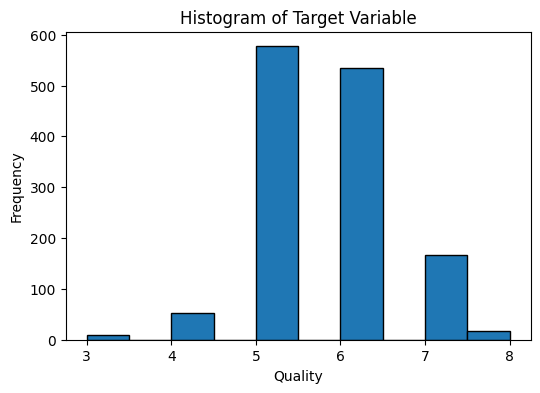

In [11]:
plt.figure(figsize=(6,4))
plt.hist(wine_data['quality'], bins=10, edgecolor='black')
plt.title("Histogram of Target Variable")
plt.xlabel("Quality")
plt.ylabel("Frequency")
plt.show()

### Detect Outliers Using Boxplot

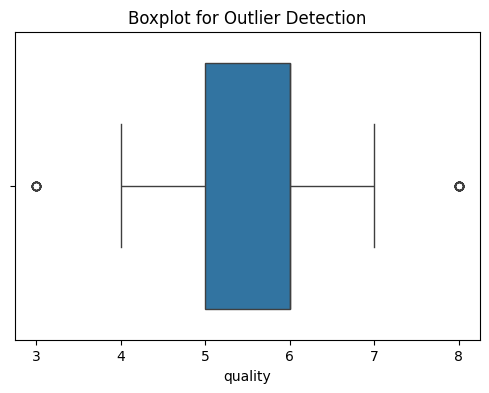

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x=wine_data['quality'])
plt.title("Boxplot for Outlier Detection")
plt.show()

### Combined Visualization

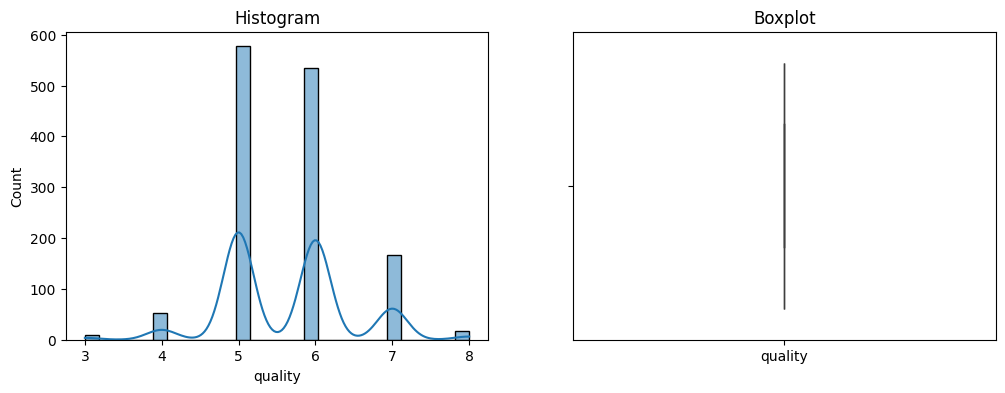

In [13]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(wine_data['quality'], kde=True)
plt.title("Histogram")

plt.subplot(1,2,2)
sns.boxplot(x=['quality'])
plt.title("Boxplot")
plt.show()

### Target Variable Analysis

In [14]:
wine_data['quality'].value_counts()

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

### Correlation Analysis

In [15]:
correlation_matrix = wine_data.corr()
print(correlation_matrix)

                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.255124     0.667437   
volatile acidity          -0.255124          1.000000    -0.551248   
citric acid                0.667437         -0.551248     1.000000   
residual sugar             0.111025         -0.002449     0.143892   
chlorides                  0.085886          0.055154     0.210195   
free sulfur dioxide       -0.140580         -0.020945    -0.048004   
total sulfur dioxide      -0.103777          0.071701     0.047358   
density                    0.670195          0.023943     0.357962   
pH                        -0.686685          0.247111    -0.550310   
sulphates                  0.190269         -0.256948     0.326062   
alcohol                   -0.061596         -0.197812     0.105108   
quality                    0.119024         -0.395214     0.228057   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity    

### Visualize Correlation Heatmap

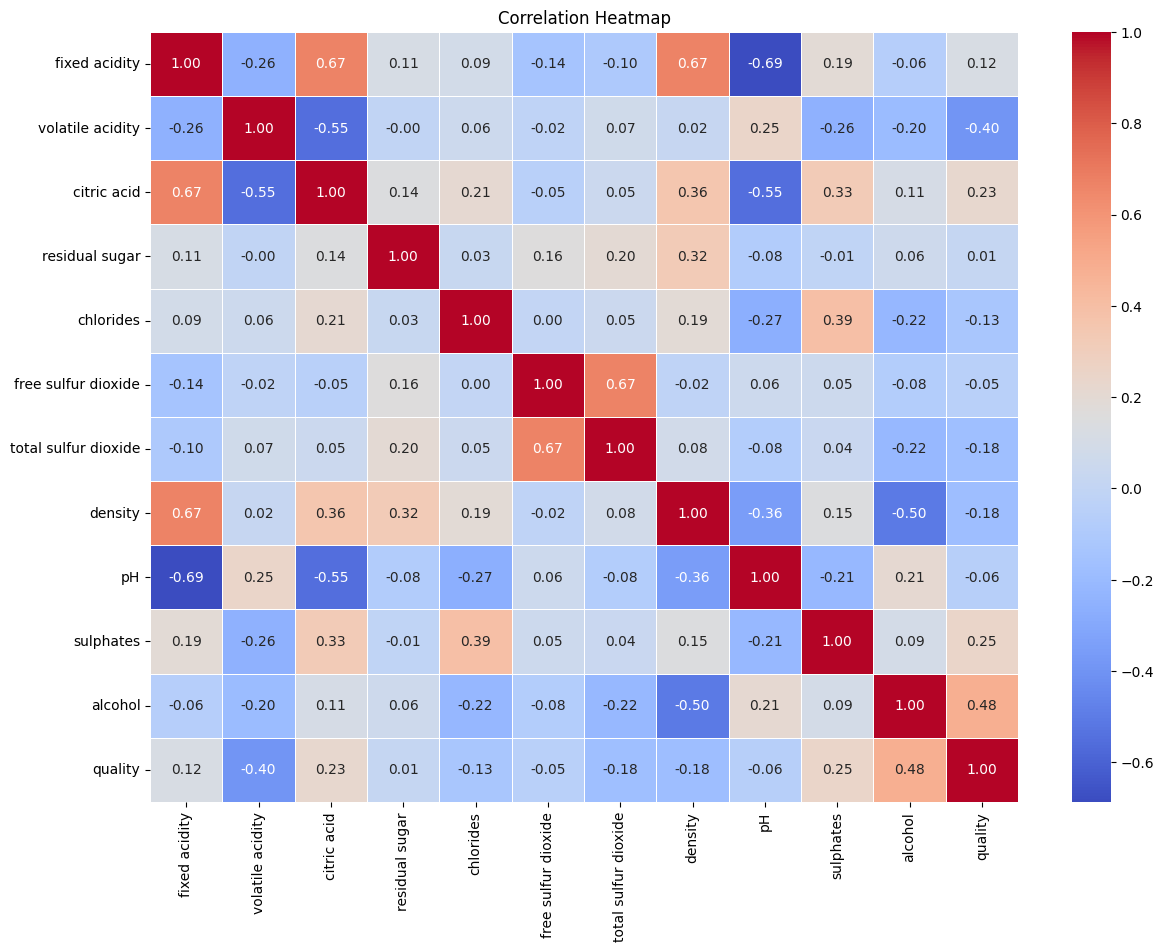

In [16]:
plt.figure(figsize=(14,10))

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Correlation with Target Variable Only

In [17]:
correlation_target = wine_data.corr()['quality'].sort_values(ascending=False)

print(correlation_target)

quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64


### Bonus

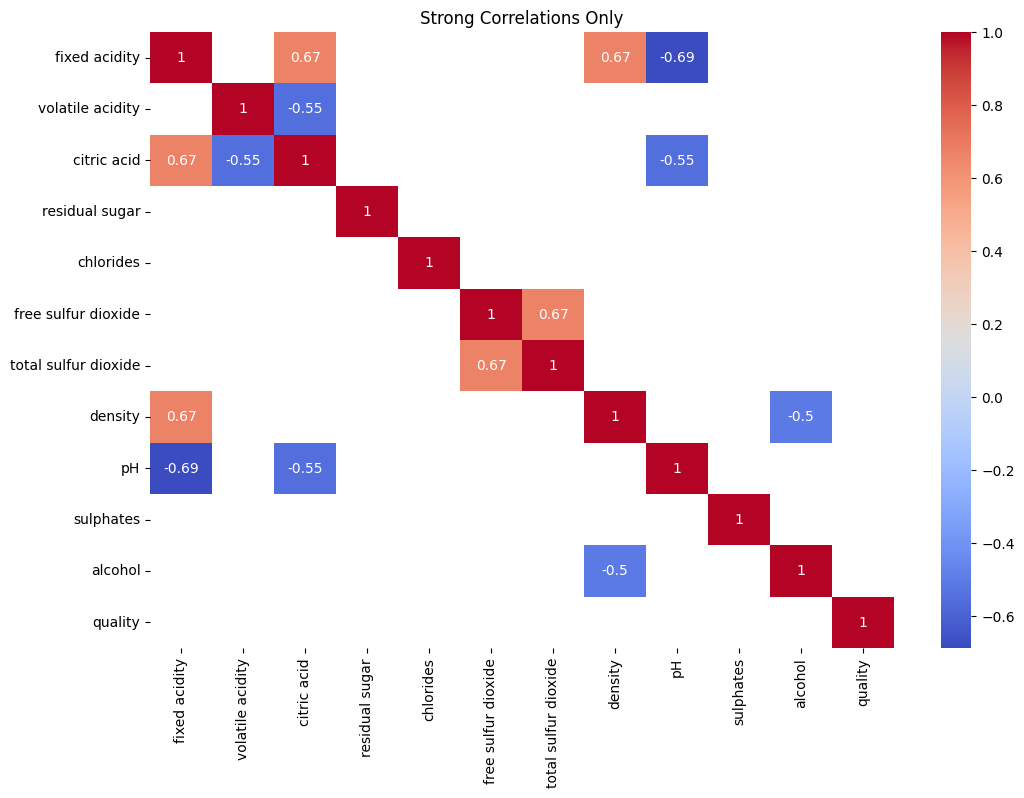

In [18]:
high_corr = correlation_matrix[abs(correlation_matrix) > 0.5]
plt.figure(figsize=(12,8))
sns.heatmap(high_corr, annot=True, cmap="coolwarm")
plt.title("Strong Correlations Only")
plt.show()

### Splitting Features and Target Variables

In [19]:
X = wine_data.drop(columns='quality',axis=1)
y = wine_data['quality']

### Feature Scaling

In [20]:
scaler = StandardScaler()
scaled_wine_data = scaler.fit_transform(X)
scaled_wine_data = pd.DataFrame(scaled_wine_data, columns=X.columns, index=X.index)
scaled_wine_data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.524431,0.932000,-1.393258,-0.461157,-0.245623,-0.468554,-0.384050,0.584003,1.291872,-0.578561,-0.954374
1,-0.294063,1.915800,-1.393258,0.056665,0.200094,0.872003,0.604073,0.048737,-0.708395,0.124822,-0.584575
2,-0.294063,1.259934,-1.188617,-0.165259,0.078535,-0.085537,0.214813,0.155790,-0.321247,-0.051024,-0.584575
3,1.664067,-1.363534,1.471711,-0.461157,-0.265883,0.105971,0.394471,0.691057,-0.966495,-0.461331,-0.584575
5,-0.524431,0.713378,-1.393258,-0.535132,-0.265883,-0.277045,-0.204391,0.584003,1.291872,-0.578561,-0.954374
...,...,...,...,...,...,...,...,...,...,...,...
1593,-0.869983,0.494756,-0.983977,-0.461157,-0.407702,1.159265,-0.264277,-0.106490,0.711149,0.945435,-0.861924
1594,-1.215536,0.385444,-0.983977,-0.387183,0.038015,1.542281,-0.084619,-0.968269,0.904724,-0.461331,0.062574
1595,-1.388312,0.112167,-0.881656,-0.239233,-0.529261,2.212559,0.124983,-0.850510,1.356397,0.593744,0.709723
1597,-1.388312,0.631395,-0.779336,-0.387183,-0.265883,1.542281,-0.084619,-0.663167,1.679021,0.300667,-0.214775


### Splitting Training Data and Testing Data

In [21]:
X_train, X_test, y_train, y_test = train_test_split(scaled_wine_data, y, test_size=0.1, stratify=y, random_state=42)

In [22]:
print(X.shape, X_train.shape,X_test.shape)

(1359, 11) (1223, 11) (136, 11)


### Splitting Testing Data into Validation Data

In [23]:
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.50, random_state=42)

In [24]:
print(X_val.shape,X_test.shape,y_val.shape,y_test.shape)

(68, 11) (68, 11) (68,) (68,)


### Random Forest Model

In [25]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Validation Prediction

In [26]:
rf_val_pred = rf_model.predict(X_val)
rf_val_accuracy = accuracy_score(y_val, rf_val_pred)
print('Random Forest Validation Accuracy:', rf_val_accuracy)

Random Forest Validation Accuracy: 0.6764705882352942


### Random Forest Hyperparameter Tuning

In [32]:
param_grid_rf = {
    'n_estimators': [50,100,150],
    'max_depth': [None,5,10]
}

grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=5)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 150}


### K-Nearest Neighbors Model

In [28]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

### Validation Prediction

In [29]:
knn_pred = knn.predict(X_val)
knn_val_accuracy = accuracy_score(y_val, knn_pred)
print('KNN Validation Accuracy:', knn_val_accuracy)

KNN Validation Accuracy: 0.6323529411764706


### KNN Hyperparameter Tuning

In [30]:
best_k = 0
best_knn_accuracy = 0

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_val)
    acc = accuracy_score(y_val, pred)

    if acc > best_knn_accuracy:
        best_knn_accuracy = acc
        best_k = k

print('Best K:', best_k)
print('Best KNN Validation Accuracy:', best_knn_accuracy)

Best K: 5
Best KNN Validation Accuracy: 0.6323529411764706


In [31]:
params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,None]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=5)

grid.fit(X_train, y_train)

grid.best_params_

{'max_depth': None, 'n_estimators': 300}

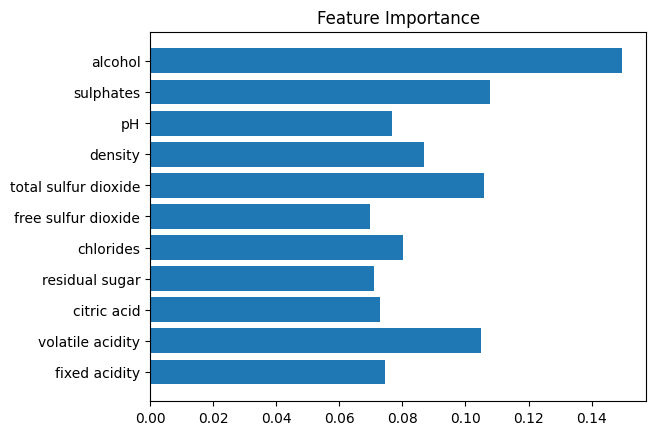

In [33]:
importance = rf.feature_importances_

feature_names = X.columns

plt.barh(feature_names, importance)
plt.title("Feature Importance")
plt.show()

### Model Comparison

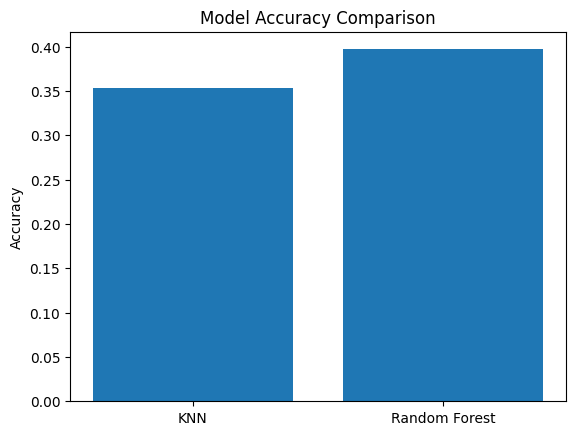

In [35]:
models = ["KNN", "Random Forest"]
accuracy = [
    accuracy_score(y_test, pred),
    accuracy_score(y_test, rf_val_pred)
]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

### Conclusion